<a href="https://colab.research.google.com/github/edoardo2496/data_science_portfolio/blob/main/titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**librerie**

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

set_style = sns.set_style('whitegrid')

dataset_titanic = sns.load_dataset('titanic')

**EDA**

In [28]:
dataset_titanic.head()
dataset_titanic.info()
dataset_titanic.describe()

# tabella riassuntiva survived
conteggio_survived = pd.pivot_table(dataset_titanic,
                                    index='survived',
                                    aggfunc='size').to_frame(name='count').reset_index()
print(conteggio_survived)

# grafico riassuntivo survived
sns.countplot(x='survived', data=dataset_titanic)
plt.show()

# Quanti valori mancanti per ogni colonna?
missing = dataset_titanic.isnull().sum()
missing_pct = (dataset_titanic.isnull().sum() / len(dataset_titanic) * 100).round(1)

pd.DataFrame({'Mancanti': missing, 'Percentuale %': missing_pct}).sort_values('Mancanti', ascending=False)

# Riempiamo i valori mancanti di age con la mediana per genere
dataset_titanic['age'] = dataset_titanic.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# Riempiamo i valori mancanti di deck con l'etichetta Unknown
dataset_titanic['deck'] = dataset_titanic['deck'].cat.add_categories('Unknown')
dataset_titanic['deck'] = dataset_titanic['deck'].fillna('Unknown')

# Riempiamo embarked ed embarked town con il valore più frequente (moda)
dataset_titanic['embarked'] = dataset_titanic['embarked'].fillna(dataset_titanic['embarked'].mode()[0])
dataset_titanic['embark_town'] = dataset_titanic['embark_town'].fillna(dataset_titanic['embark_town'].mode()[0])


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


**grafici**

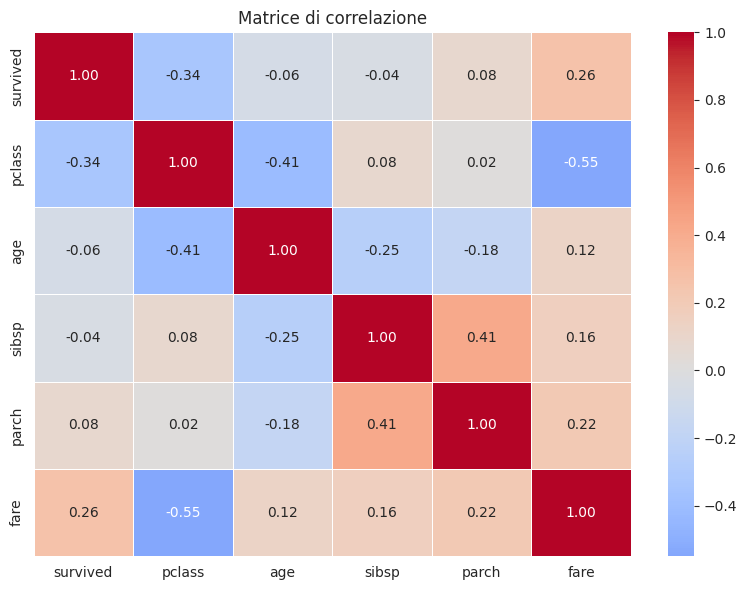

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: Sopravvissuti per sesso
dataset_titanic.groupby('sex')['survived'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black'
)
axes[0].set_title('Tasso di sopravvivenza per sesso')
axes[0].set_ylabel('Probabilità di sopravvivenza')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

# Grafico 2: Sopravvissuti per classe
dataset_titanic.groupby('pclass')['survived'].mean().plot(
    kind='bar', ax=axes[1], color=['gold', 'silver', '#cd7f32'], edgecolor='black'
)
axes[1].set_title('Tasso di sopravvivenza per classe')
axes[1].set_ylabel('Probabilità di sopravvivenza')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

pivot = dataset_titanic.groupby(['pclass', 'sex'])['survived'].mean().unstack()

pivot.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Tasso di sopravvivenza per classe e sesso')
plt.ylabel('Probabilità di sopravvivenza')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Sesso')
plt.tight_layout()
plt.show()

# Vediamo anche i numeri precisi
print(pivot.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribuzione età: sopravvissuti vs non
dataset_titanic[dataset_titanic['survived'] == 1]['age'].plot(
    kind='hist', ax=axes[0], bins=30, alpha=0.6, color='green', label='Sopravvissuti'
)
dataset_titanic[dataset_titanic['survived'] == 0]['age'].plot(
    kind='hist', ax=axes[0], bins=30, alpha=0.6, color='red', label='Non sopravvissuti'
)
axes[0].set_title('Distribuzione età: sopravvissuti vs non')
axes[0].set_xlabel('Età')
axes[0].legend()

# Creiamo fasce d'età per vedere il tasso di sopravvivenza
dataset_titanic['fascia_eta'] = pd.cut(
    dataset_titanic['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Bambini', 'Adolescenti', 'Giovani adulti', 'Adulti', 'Anziani']
)

dataset_titanic.groupby('fascia_eta')['survived'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Tasso di sopravvivenza per fascia d\'età')
axes[1].set_ylabel('Probabilità di sopravvivenza')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Tasso di sopravvivenza bambini vs adulti, diviso per sesso
dataset_titanic['is_bambino'] = dataset_titanic['age'] < 12

print(dataset_titanic.groupby(['is_bambino', 'sex'])['survived'].mean().round(2))

import seaborn as sns

# Selezioniamo solo le colonne numeriche
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

corr = dataset_titanic[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

**ML classificatore**

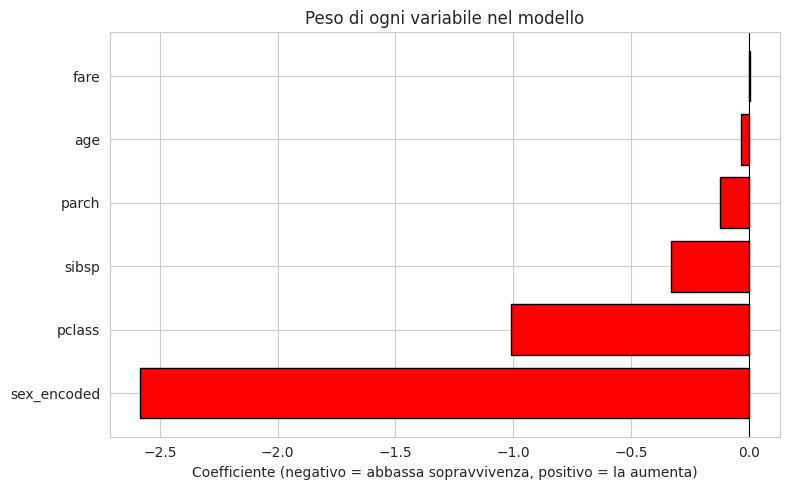

    Feature  Coefficiente
sex_encoded     -2.582350
     pclass     -1.010431
      sibsp     -0.329819
      parch     -0.120746
        age     -0.035031
       fare      0.003100


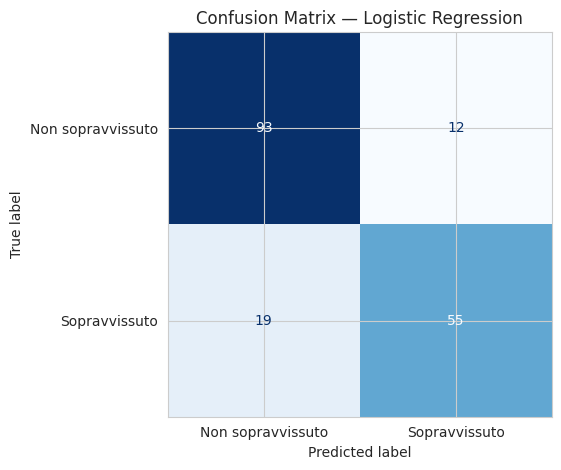

Veri Negativi  (TN): 93 → morti che il modello ha indovinato
Falsi Positivi (FP): 12 → morti che il modello pensava sopravvivessero
Falsi Negativi (FN): 19 → sopravvissuti che il modello pensava morti
Veri Positivi  (TP): 55 → sopravvissuti che il modello ha indovinato


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Selezioniamo le feature (variabili input) e il target (cosa vogliamo predire)
features = ['pclass', 'age', 'fare', 'sibsp', 'parch', 'sex']
target = 'survived'

# Convertiamo sex in numero: female=0, male=1
dataset_titanic['sex_encoded'] = LabelEncoder().fit_transform(dataset_titanic['sex'])

features = ['pclass', 'age', 'fare', 'sibsp', 'parch', 'sex_encoded']

X = dataset_titanic[features]
y = dataset_titanic[target]

# Dividiamo in training set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} passeggeri")
print(f"Test set: {X_test.shape[0]} passeggeri")

# Creiamo e addestriamo il modello
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Facciamo le predizioni sul test set
y_pred = model.predict(X_test)

# Valutiamo le performance
print(f"Accuratezza: {accuracy_score(y_test, y_pred):.2%}\n")
print("Report dettagliato:")
print(classification_report(y_test, y_pred, target_names=['Non sopravvissuto', 'Sopravvissuto']))

import numpy as np

# Visualizziamo i pesi (coefficienti) del modello
coeff = pd.DataFrame({
    'Feature': features,
    'Coefficiente': model.coef_[0]
}).sort_values('Coefficiente', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['red' if c < 0 else 'green' for c in coeff['Coefficiente']]
plt.barh(coeff['Feature'], coeff['Coefficiente'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Peso di ogni variabile nel modello')
plt.xlabel('Coefficiente (negativo = abbassa sopravvivenza, positivo = la aumenta)')
plt.tight_layout()
plt.show()

print(coeff.to_string(index=False))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non sopravvissuto', 'Sopravvissuto'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Vediamo anche i numeri espliciti
tn, fp, fn, tp = cm.ravel()
print(f"Veri Negativi  (TN): {tn} → morti che il modello ha indovinato")
print(f"Falsi Positivi (FP): {fp} → morti che il modello pensava sopravvivessero")
print(f"Falsi Negativi (FN): {fn} → sopravvissuti che il modello pensava morti")
print(f"Veri Positivi  (TP): {tp} → sopravvissuti che il modello ha indovinato")

**Random Forest**

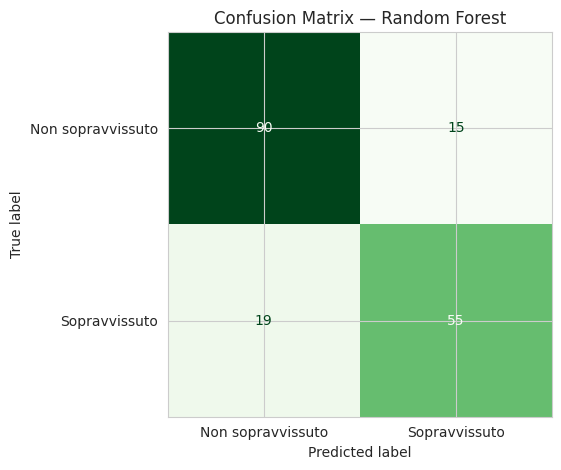

Logistic Regression: 82.68%
Random Forest v1:    81.01%
Random Forest v2:    79.89%


In [40]:
from sklearn.ensemble import RandomForestClassifier

# Creiamo il modello
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predizioni
y_pred_rf = rf_model.predict(X_test)

# Accuratezza
print(f"Logistic Regression: 82.68%")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Non sopravvissuto', 'Sopravvissuto'])
disp.plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

rf_model_v2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,        # limitiamo la profondità degli alberi
    min_samples_leaf=5, # ogni foglia deve avere almeno 5 campioni
    random_state=42
)
rf_model_v2.fit(X_train, y_train)
y_pred_rf2 = rf_model_v2.predict(X_test)

print(f"Logistic Regression: 82.68%")
print(f"Random Forest v1:    81.01%")
print(f"Random Forest v2:    {accuracy_score(y_test, y_pred_rf2):.2%}")